<a href="https://colab.research.google.com/github/IgnacioAntonio82/AprendizajeAutomatico2/blob/main/TrabajoPractico1AA2/TRABAJO_PR%C3%81CTICO_Nro_1_AA2_Aguilar_Ignacio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 AA1

**Autor**: **Ignacio Antonio Aguilar**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

In [119]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np



In [120]:
## el data set elegido es  Forty Soybean Cultivars from Subsequent Harvests

##cargo el data set
url="https://raw.githubusercontent.com/IgnacioAntonio82/AprendizajeAutomatico2/main/TrabajoPractico1AA2/data.csv"
df = pd.read_csv(url, sep=',', encoding='latin-1')
df.head(10)##Cargo el archivo csv y muestro los primeros 10 registros, para verificar si trae correctamente

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
0,1,NEO 760 CE,1,58.80,15.20,98.2,177.80,1.81,5.20,152.20,3232.82
1,1,NEO 760 CE,2,58.60,13.40,102.0,195.00,1.85,7.20,141.69,3517.36
2,1,NEO 760 CE,3,63.40,17.20,100.4,203.00,2.02,6.80,148.81,3391.46
3,1,NEO 760 CE,4,60.27,15.27,100.2,191.93,1.89,6.40,148.50,3312.58
4,1,MANU IPRO,1,81.20,18.00,98.8,173.00,1.75,7.40,145.59,3230.99
5,1,MANU IPRO,2,75.80,20.80,69.2,128.00,1.85,7.20,154.87,3374.80
6,1,MANU IPRO,3,84.40,15.80,95.4,161.80,1.70,6.80,150.23,3182.76
7,1,MANU IPRO,4,80.47,18.20,87.8,154.27,1.77,7.13,149.90,3165.72
8,1,77HO111I2X - GUAPORÃ,1,52.20,14.40,64.8,148.80,2.30,7.20,180.25,3640.46
9,1,77HO111I2X - GUAPORÃ,2,55.80,15.80,72.0,188.80,2.62,6.20,176.75,3602.34


##Explicacion Significado de Features
- Season → Campaña agrícola / año.

- Cultivar → Genotipo / variedad / híbrido.

- Repetition → Número de la repetición (bloque experimental).

- PH → Altura de planta (cm).

- IFP → Inserción de la primera vaina (cm).

- NLP → Número de vainas por planta.

- NGP → Número de granos por planta.

- NGL → Número de granos por vaina (o lóculo).

- NS → Número de semillas por vaina / nodo (según definición en tu protocolo).

- MHG → Peso de 100 semillas (g).

- GY → Rendimiento en grano (kg/ha, probablemente).


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

In [121]:
# 1. Estadísticas descriptivas
df.describe()


,Season,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
count,320.000000,320.000000,320.000000,320.0000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,1.500000,2.500000,68.386781,15.4650,59.088313,135.085844,2.290844,4.071656,168.322313,3418.553794
std,0.500783,1.119785,8.958194,3.0243,20.068187,60.494529,0.840116,1.474531,19.625566,503.003602
min,1.000000,1.000000,47.600000,7.2000,20.200000,47.800000,0.940000,0.400000,127.060000,1538.230000
25%,1.000000,1.750000,62.950000,13.6000,44.350000,95.052500,2.000000,3.000000,153.845000,3126.611552
50%,1.500000,2.500000,67.200000,15.6000,54.500000,123.000000,2.280000,3.800000,166.150000,3397.276724
75%,2.000000,3.250000,74.347500,17.3300,71.220000,161.350000,2.480000,5.000000,183.182500,3708.262931
max,2.000000,4.000000,94.800000,26.4000,123.000000,683.400000,14.860000,9.000000,216.000000,4930.000000


##Interpretacion de cada variable
- count: Hay 320 observaciones
### PH (Plant Height = Altura de planta, cm)

- Media = 68.4 cm,
- Rango = 47.6 – 94.8 cm.
- 25% < 63 cm, la mayoría de las plantas no supera los 75 cm.
- Variabilidad moderada (std 8.96), es decir, no hay diferencias extremas en altura.

###IFP (Inflorescence Primary, cm / largo de inflorescencia primaria)

- Media = 15.5 cm, rango 7.2 – 26.4 cm.
- Valores entre 13.6 y 17.3 cm (25–75%) son lo más frecuente.
- Variabilidad moderada (std 3.02).

###NLP (Número de lóculos por planta / vainas por planta, según el cultivo)

- Media = 59.1, rango 20.2 – 123.
- El 50% de los casos cae entre 44 y 71.
- Desviación relativamente alta (std 20.1)

### NGP (Número de granos por planta)

- Media = 135, pero el máximo llega a 683.4, lo que es un outlier fuerte.
- El 50% central está entre 95 y 161, valores más razonables.
- La dispersión (std 60.5) es muy alta.

### NGL (Número de granos por lóculo / vaina)

- Media = 2.29, rango 0.94 – 14.86.
- La mayoría de los datos se concentran entre 2 y 2.5 (percentiles 25–75).
- El máximo (14.86) parece un valor atípico o error de medición

### NS (Número de semillas por espiga o similar)

- Media = 4.07, rango 0.4 – 9.
- 50% central entre 3 y 5, lo cual muestra baja dispersión.
- Valores mínimos (0.4) indican plantas muy poco productivas.

### MHG (Mil Hojas de Grano o Peso de 1000 granos, g)

- Media = 168.3 g, rango 127 – 216 g.
- La mayoría entre 154 y 183 g (percentiles 25–75).
- Variabilidad moderada (std 19.6).

### GY (Grain Yield = rendimiento de grano, kg/ha o g/planta según diseño)

- Media = 3419, rango 1538 – 4930.
- 50% central entre 3126 y 3708, lo que indica una productividad media-alta.
- Desviación (503) muestra que hay diferencias importantes.









In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Season      320 non-null    int64  
 1   Cultivar    320 non-null    object 
 2   Repetition  320 non-null    int64  
 3   PH          320 non-null    float64
 4   IFP         320 non-null    float64
 5   NLP         320 non-null    float64
 6   NGP         320 non-null    float64
 7   NGL         320 non-null    float64
 8   NS          320 non-null    float64
 9   MHG         320 non-null    float64
 10  GY          320 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 27.6+ KB


In [123]:
df.shape

(320, 11)

In [124]:
# Identificar variables categóricas por tipo de dato (object, category)
categorical_vars = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_vars

['Cultivar']

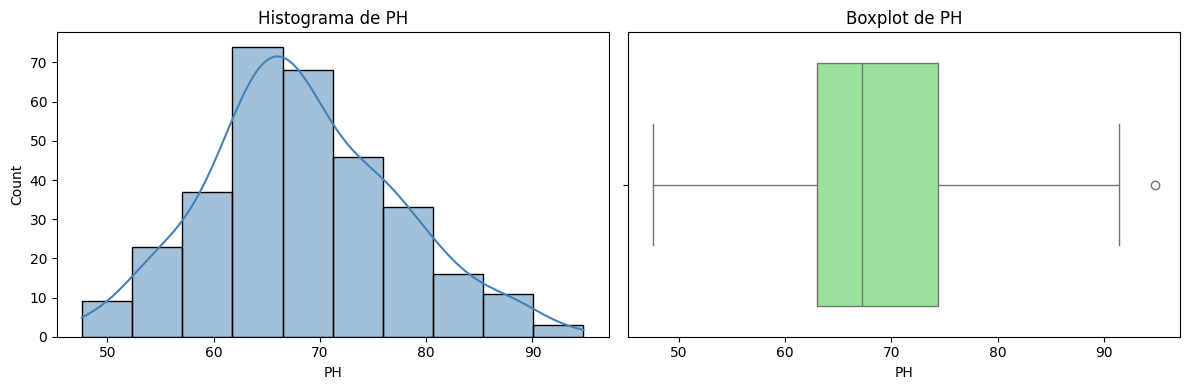

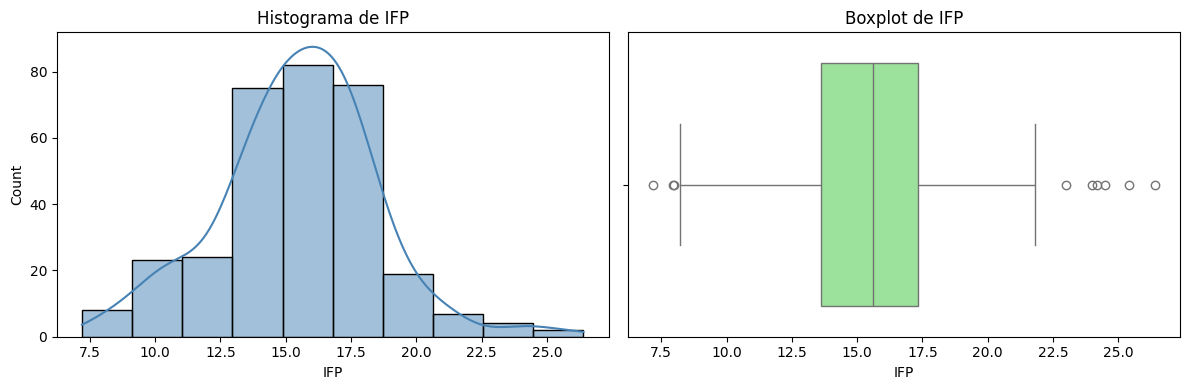

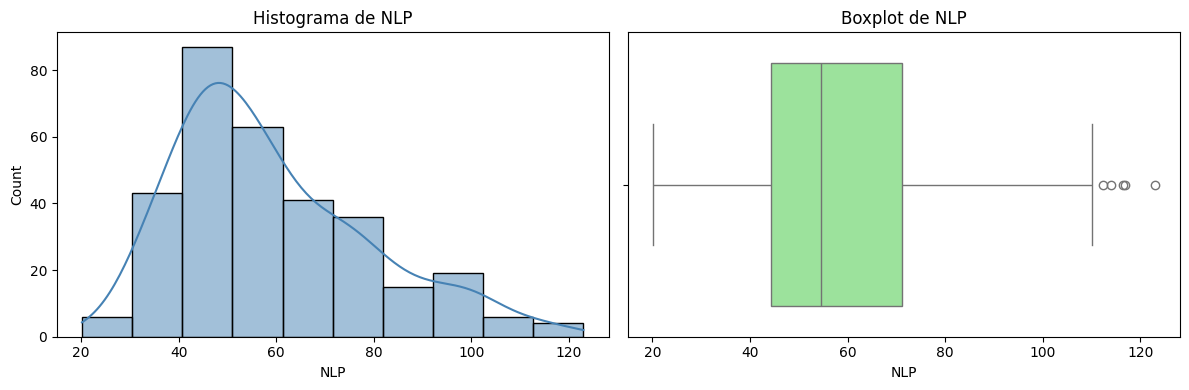

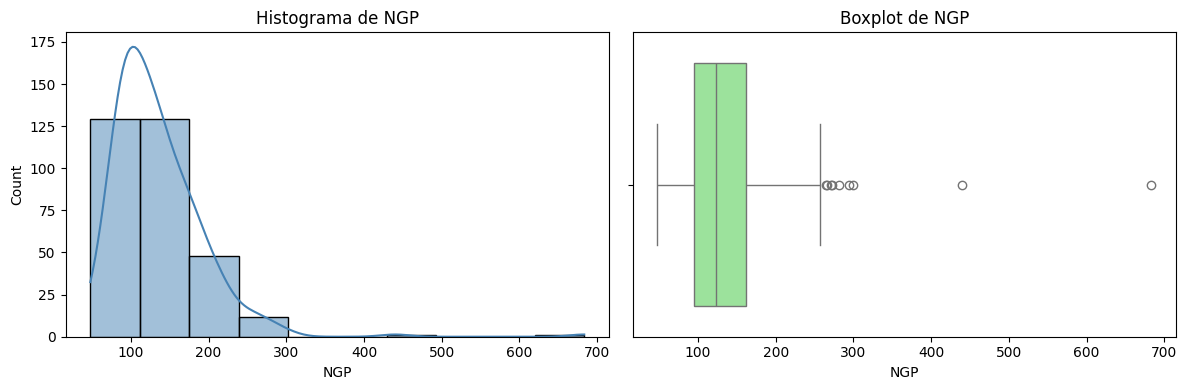

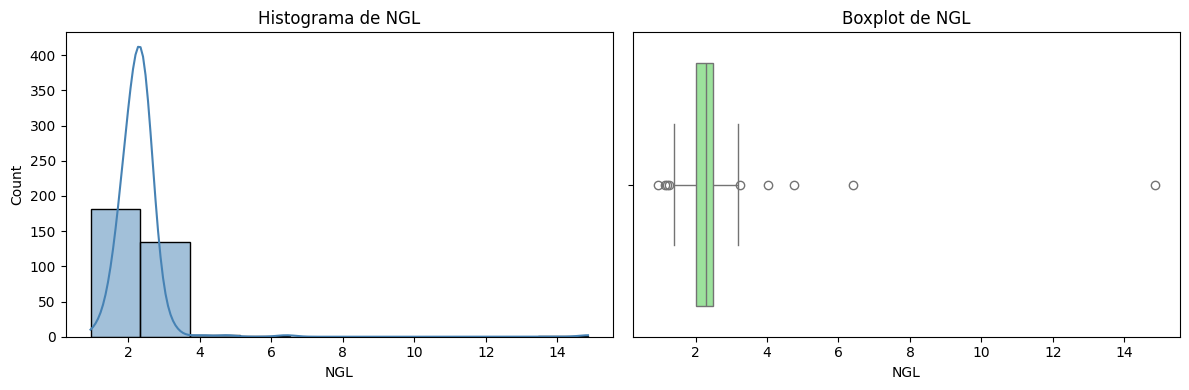

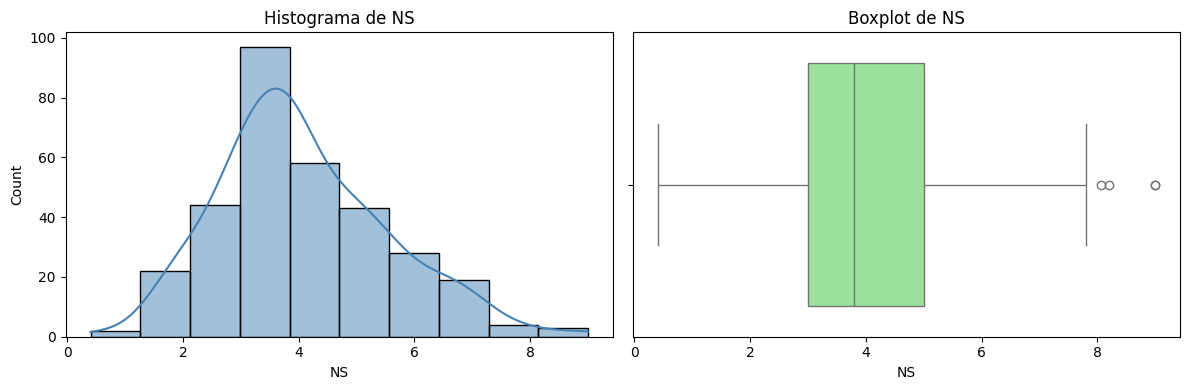

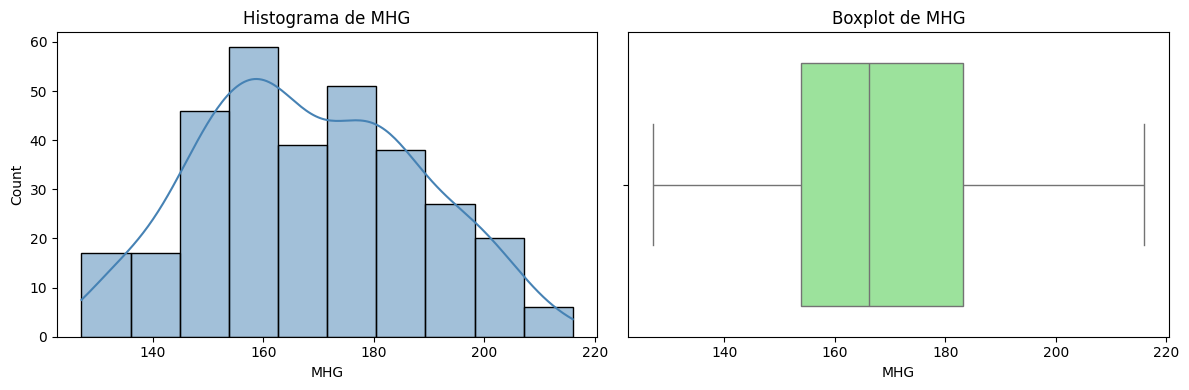

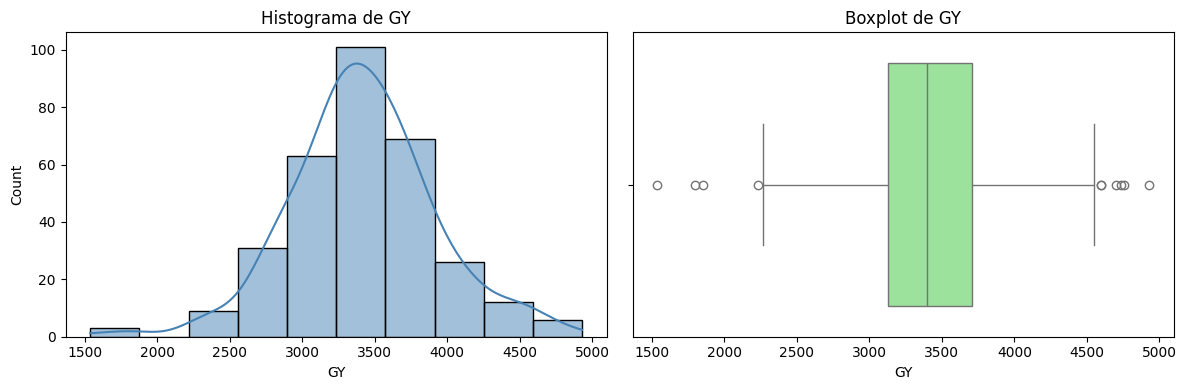

In [125]:
## Histogramas o boxplots para ver distribuciones

features = ["PH", "IFP", "NLP", "NGP", "NGL", "NS", "MHG", "GY"]
# Define las variables que querés analizar.

for col in features:
    plt.figure(figsize=(12,4)) #Crea una nueva figura (gráfico) de 12x4 pulgadas para cada variable.

    # Histograma
    plt.subplot(1,2,1) #Divide la figura en una cuadrícula de subgráficos
    sns.histplot(df[col], kde=True, bins=10, color="steelblue")
    # Genera un histograma de la columna col del DataFrame df:
    # bins=10 → divide los valores en 10 intervalos (barras).
    #color="steelblue" → pinta las barras de azul acero.
    # kde=True → añade la curva de densidad estimada para ver cómo se distribuyen los datos suavemente
    plt.title(f"Histograma de {col}")
    #Le pone un título dinámico al gráfico

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()

### Interpretacion Histograma / Boxplot de Algunos graficos

## histograma y un boxplot de la variable PH (Plant Height = Altura de planta)
## Histograma
- curva aproximadamente normal
- es bastante simétrica
## Boxplot
- Outlier: aparece un valor aislado cerca de 95 cm
- Bigotes (mín–máx sin outliers): se extienden desde ~48 cm hasta ~92 cm
- Mediana: está alrededor de 67 cm
- Caja (IQR: 25%–75%): se concentra entre 63 y 74 cm

## histograma y un boxplot de IFP (longitud de inflorescencia primaria, en cm)
## Histograma
- Forma: distribución cercana a la normal
## Boxplot
- Outliers:
- - En el extremo bajo: valores cercanos a 7.5–8 cm, plantas con inflorescencias muy cortas.
- - En el extremo alto: varios puntos aislados por encima de 22 cm, llegando hasta ~26 cm
- Bigotes (sin outliers): van de ~10 a ~21 cm.
- Caja (IQR): concentra el 50% de los datos entre 13.6 y 17.3 cm, lo que indica que la mayoría está bien agrupada.

# histograma y un boxplot de  NLP (Número de lóculos/vainas por planta):
## Histograma
- Distribución: asimétrica hacia la derecha
## Boxplot
- Outliers: aparecen varios puntos aislados en el extremo alto (≥115)
- Bigotes (sin outliers): se extienden hasta valores cercanos a 110 vainas
- Caja (IQR): entre 44 y 71 vainas, abarca el 50% de los datos centrales

# histograma y un boxplot de NGP (Número de granos por planta):
## Histograma
- Distribución: La distribución es asimétrica positiva (sesgada a la derecha)

## Boxplot
- Outliers: aparecen múltiples puntos extremos
- Bigotes (sin outliers): se extienden hasta valores cercanos a 250–280.
- Caja (IQR): entre ~95 y 160 granos, donde se ubica el 50% de los datos.

# histograma y un boxplot de  NGL (Número de granos por lóculo / vaina):
## Histograma
- Distribución: La distribución es asimétrica positiva

## Boxplot
- El cajón verde muestra que el rango intercuartílico (IQR) va aproximadamente entre 2 y 3.
- La mediana está cerca de 2,5.
- Existen outliers a la derecha: valores de 4, 6 y un caso extremo alrededor de 15.
- También se observan algunos outliers menores en la parte baja, aunque pocos.





##Mapa de Calor

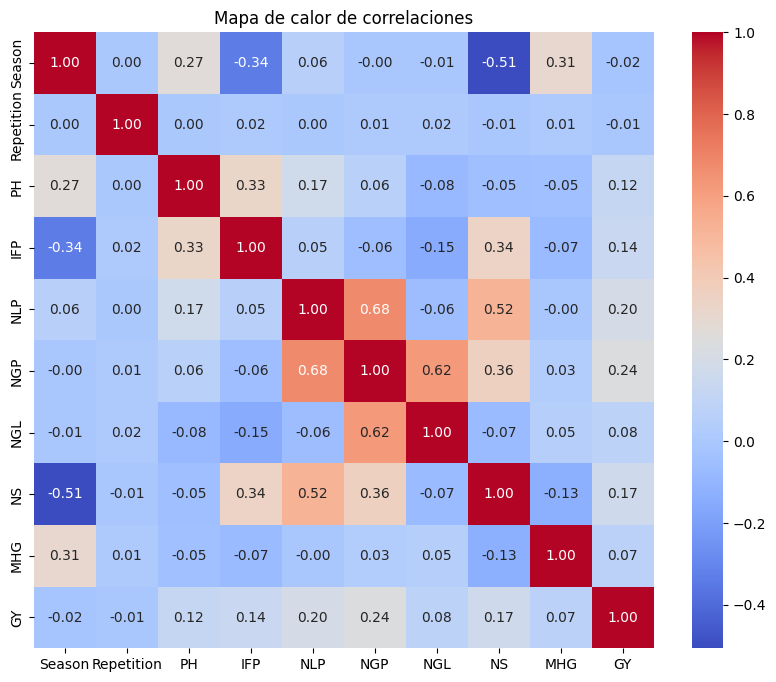

In [126]:
# Seleccionar únicamente variables numéricas
df_num = df.select_dtypes(include='number')

plt.figure(figsize=(10,8))
sns.heatmap(
    df_num.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Mapa de calor de correlaciones")
plt.show()

### Interpretacion
* Se observa una correlación positiva de 0.68 entre NGP (número de granos por planta) y NLP (número de vainas por planta). Esto indica que, en general, las plantas con mayor cantidad de vainas tienden a presentar también un mayor número de granos por planta. La relación es de intensidad moderadamente fuerte.

* Asimismo, existe una correlación positiva de 0.62 entre NGP (número de granos por planta) y NGL (número de granos por vaina). Esto sugiere que las plantas que presentan un mayor número de granos por vaina tienden a tener también un mayor número total de granos por planta. La relación también es moderadamente fuerte.

* La correlación entre NS y Season es de -0.51, lo que indica una correlación negativa moderada. Esto significa que, en las campañas agrícolas analizadas, a medida que aumenta el año de la campaña, el número de semillas por vaina tiende a disminuir. Una posible explicación es que las condiciones de cada campaña agrícola no fueron las mismas. Factores como las precipitaciones, la temperatura, la disponibilidad de agua, el manejo del cultivo o el estrés hídrico pueden haber influido en la cantidad de semillas por vaina. No obstante, el análisis de correlación por sí solo no permite determinar cuál fue la causa de esta relación.

In [127]:
# 3. Scatterplots de features vs target
# -------------------------
# Scatterplots vs Rendimiento (GY)
# -------------------------
# Scatterplots interactivos
for col in features:  #Recorre todas las columnas listadas en features, excepto la variable GY (porque esa ya se usa como variable de salida en el eje y).
    if col != "GY":
        fig = px.scatter(  #Crea un diagrama de dispersión
            df,
            x=col, #el eje X será la variable independiente
            y="GY", #el eje Y siempre será el rendimiento
            color="Cultivar",   # los puntos se colorean según la categoría de Cultivar (esto ayuda a comparar grupos).
            title=f"{col} vs Rendimiento (GY)", #título dinámico con el nombre de la variable
            template="plotly_white", # estilo limpio con fondo blanco
            trendline="ols",          # Línea de regresión
            trendline_scope="overall",# dibuja una sola línea de tendencia global usando todos los cultivares juntos.
            hover_data=df.columns  # para que muestre más info al pasar el mouse
        )
        fig.show()



Pregunta clave: ¿Qué relaciones lineales preliminares observan?

Los diagramas de dispersión confirman lo observado en el mapa de calor de correlaciones. En general, se aprecia una tendencia positiva entre las variables explicativas y el rendimiento (GY), lo cual coincide con los coeficientes de correlación positivos obtenidos anteriormente.

Sin embargo, en la mayoría de los gráficos existe una alta dispersión de los datos alrededor de la línea de regresión, lo que indica que la relación lineal entre cada variable y el rendimiento no es fuerte cuando se analizan de forma individual.

La mayor dispersión se observa en la relación entre NGL (número de granos por vaina) y GY, donde los puntos se encuentran muy dispersos y la pendiente de la recta es pequeña, sugiriendo una asociación lineal débil.

Además, se identifican algunos valores atípicos (outliers), especialmente en las variables NGP y NGL, que podrían influir en el ajuste de la recta de regresión.



## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

In [128]:
# --- 1. Detectar valores faltantes ---
print("Valores faltantes por columna:")

missing_values = df.isnull().sum()

# 2. Detectar outliers usando el criterio IQR en las variables numéricas
outlier_info = {}
for col in ["PH","IFP","NLP","NGP","NGL","NS","MHG","GY"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_info[col] = len(outliers)

missing_values, outlier_info



Valores faltantes por columna:


(Season        0
 Cultivar      0
 Repetition    0
 PH            0
 IFP           0
 NLP           0
 NGP           0
 NGL           0
 NS            0
 MHG           0
 GY            0
 dtype: int64,
 {'PH': 1,
  'IFP': 9,
  'NLP': 5,
  'NGP': 9,
  'NGL': 9,
  'NS': 4,
  'MHG': 0,
  'GY': 10})

Resultado: No hay valores nulos, lo que facilita el análisis.
###Respecto a los outliers
- PH (Altura de planta): 1 outlier.
- IFP (Índice de fecundidad por planta): 9 outliers.
- NLP (Nº de legumbres por planta): 5 outliers.
- NGP (Nº de granos por planta): 9 outliers.
- NGL (Nº de granos por legumbre): 9 outliers.
- NS (Nº de semillas por legumbre): 4 outliers.
- GY (Rendimiento en grano): 10 outliers.
- MHG (Masa de 100 granos): sin outliers detectados.
###No parecen ser errores de carga, Conviene no eliminarlos

In [129]:
#Limpieza: indique cuáles features descarta. Justifique.

#Las features a descartar son:

#Repetition: No aporta a la predicción Cada repetición corresponde a una parcela o unidad experimental diferente donde se evaluó el mismo
# cultivar bajo condiciones similares. Su objetivo es reducir el efecto de la variabilidad del terreno y obtener resultados más confiables.

#Season: no voy a realizar un analisis por año.

print("Features descartadas:")
print("- Repetition: corresponde a la repetición del diseño experimental y no aporta información predictiva sobre el cultivar.")
print("- Season: identifica la temporada de cosecha. Se elimina para evitar que el modelo dependa de una temporada específica y se enfoque en las características propias del cultivar.")

## elimino los features a descartar
df_clean = df.drop(columns=["Repetition", "Season"])
# Mostrar info y primeras filas
df_clean


Features descartadas:
- Repetition: corresponde a la repetición del diseño experimental y no aporta información predictiva sobre el cultivar.
- Season: identifica la temporada de cosecha. Se elimina para evitar que el modelo dependa de una temporada específica y se enfoque en las características propias del cultivar.


,Cultivar,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
0,NEO 760 CE,58.80,15.20,98.20,177.80,1.81,5.20,152.20,3232.820000
1,NEO 760 CE,58.60,13.40,102.00,195.00,1.85,7.20,141.69,3517.360000
2,NEO 760 CE,63.40,17.20,100.40,203.00,2.02,6.80,148.81,3391.460000
3,NEO 760 CE,60.27,15.27,100.20,191.93,1.89,6.40,148.50,3312.580000
4,MANU IPRO,81.20,18.00,98.80,173.00,1.75,7.40,145.59,3230.990000
...,...,...,...,...,...,...,...,...,...
315,FTR 4288 IPRO,88.33,16.33,75.73,139.00,1.84,3.67,135.19,3348.931034
316,FTR 3190 IPRO,64.40,16.60,76.00,168.00,2.21,3.60,145.69,3418.850575
317,FTR 3190 IPRO,64.60,17.60,116.80,271.20,2.32,3.80,147.24,3651.586207
318,FTR 3190 IPRO,58.80,14.80,86.40,180.60,2.09,2.20,156.32,3487.931034


#Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adecuado.

> Variables categóricas

Se utilizará únicamente la variable categórica Cultivar, ya que representa el genotipo o la variedad de soja. Esta variable puede influir directamente en el rendimiento (GY), debido a que cada cultivar posee características genéticas diferentes que afectan el crecimiento, la producción de granos y la adaptación a las condiciones ambientales.

Las variables Season y Repetition no se utilizarán en el modelo. Season identifica la campaña agrícola y puede reflejar condiciones particulares de un año específico, mientras que Repetition corresponde a la repetición del ensayo experimental y no representa una característica propia del cultivo. Además, en el análisis exploratorio ambas variables mostraron una baja correlación con el rendimiento y no aportan información relevante para predecir la variable objetivo.



###Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.
#Para poder comparar coeficientes
## 1- Codificar la variable categórica Cultivar (usando One-Hot Encoding).
### 2 -Escalar las features numéricas con StandardScaler para que estén en la misma escala (media = 0, desviación estándar = 1).




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


In [130]:
# Definir X e y
X = df_clean.drop(columns=["GY"]) #todas las variables independientes
y = df_clean["GY"] #la variable dependiente a predecir

# Identificar variables categóricas y numéricas
categorical_features = [ "Cultivar" ]
numeric_features = [col for col in X.columns if col not in categorical_features]

# Preprocesamiento: OneHot para categóricas, dejar numéricas igual
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        #convierte Cultivar en variables dummy (0/1)
        #(drop="first")evita multicolinealidad (se elimina la primera categoría como referencia)
        ("num", RobustScaler(), numeric_features)  # <-- Escalar numéricas
        # RobustScaler → normaliza las variables numéricas usando mediana y rango intercuartílico (robusto frente a outliers).
    ]
)

# Pipeline con preprocesamiento + regresión
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
#Aplica un preprocesamiento a los datos de entrada antes de entrenar el modelo
#Una vez transformados los datos, entrena un modelo de regresión lineal con esas variables procesadas


# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Separa 80% de datos para entrenamiento y 20% para test.
#random_state=42 → hace que la división sea reproducible.

# Ajustar el modelo
model.fit(X_train, y_train)

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
#Genera predicciones tanto en train como en test.

# Métricas
#calcula las metricas
#R² (train/test) → mide cuánto del rendimiento (GY) logra explicar el modelo.
#MSE (train/test) → Mean Squared Error, el error cuadrático medio.
  #Penaliza fuerte errores grandes.
  #Mientras más chico, mejor.
#MAE (train/test) → Mean Absolute Error, error absoluto medio.
#Da una idea del error promedio en las mismas unidades que la variable objetivo (ej: kg/ha).

print("📊 Métricas del modelo reducido:")

metrics_df = pd.DataFrame({
    "Métrica": ["R²", "MSE", "MAE"],
    "Train": [
        r2_score(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred),
        mean_absolute_error(y_train, y_train_pred)
    ],
    "Test": [
        r2_score(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred)
    ]
})

print(metrics_df)



# obtienes el nombre correcto de cada variable después del One-Hot Encoding.
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": model.named_steps["regressor"].coef_
}).sort_values(by="Coeficiente", key=lambda x: x.abs(), ascending=False)

# Ordenar por importancia
# Recupera los nombres de las variables transformadas
# Muestra los coeficientes estimados por la regresión lineal.
# Ordena por magnitud absoluta → ayuda a ver qué variables tienen más impacto en el rendimiento.

# Intercepto
intercept = model.named_steps["regressor"].intercept_
#Obtiene el intercepto del modelo (valor base de GY).

print("\n🔹 Intercepto del modelo:")
print(intercept)

print("\n🔹 Coeficientes del modelo (ordenados por valor absoluto):")
print(coefficients)

📊 Métricas del modelo reducido:
  Métrica          Train           Test
0      R²       0.588538       0.522910
1     MSE  103078.120567  123529.507901
2     MAE     253.617012     274.922042

🔹 Intercepto del modelo:
3405.6883570341233

🔹 Coeficientes del modelo (ordenados por valor absoluto):
                                      Variable  Coeficiente
5                     cat__Cultivar_96R29 IPRO -1098.011731
28                cat__Cultivar_MONSOY 8330I2X   751.153102
33                  cat__Cultivar_NK 8100 IPRO  -719.748844
10           cat__Cultivar_BRASMAX BÃNUS IPRO  -643.620900
15                cat__Cultivar_FORTALEZA IPRO   623.065548
6                     cat__Cultivar_97Y97 IPRO  -576.204975
3                  cat__Cultivar_82I78RSF IPRO  -550.594475
36                     cat__Cultivar_SUZY IPRO   510.857044
14          cat__Cultivar_FORTALECE L090183 RR   486.692408
4                  cat__Cultivar_83IX84RSF I2X   479.608247
23                    cat__Cultivar_LAT 1330

Los coeficientes fueron ordenados según su valor absoluto, por lo que las primeras variables corresponden a aquellas con mayor influencia estimada sobre la predicción del rendimiento. El signo del coeficiente indica la dirección del efecto (positivo o negativo), mientras que su magnitud refleja la intensidad de dicho efecto.

In [131]:
# 1. Crear los datos de la tabla
data = {
    "Métrica": ["R²", "MSE", "MAE"],
    "Train": [0.589, 103078, 253.62],
    "Test": [0.523, 123529, 274.92],
    "Interpretación": [
        "El modelo explica aproximadamente el 58.9 % de la variabilidad del rendimiento en entrenamiento y el 52.3 % en prueba.",
        "El error cuadrático medio es mayor en el conjunto de prueba, lo cual es esperable.",
        "En promedio, el modelo se equivoca aproximadamente 275 unidades de GY en el conjunto de prueba."
    ]
}

# 2. Crear el DataFrame
df = pd.DataFrame(data)

# 3. Mostrar la tabla con un estilo elegante alineado a la izquierda para el texto
df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Métrica,Train,Test,Interpretación
R²,0.589000,0.523000,El modelo explica aproximadamente el 58.9 % de la variabilidad del rendimiento en entrenamiento y el 52.3 % en prueba.
MSE,103078.000000,123529.000000,"El error cuadrático medio es mayor en el conjunto de prueba, lo cual es esperable."
MAE,253.620000,274.920000,"En promedio, el modelo se equivoca aproximadamente 275 unidades de GY en el conjunto de prueba."


## Conlcusion


El modelo presenta un desempeño similar en entrenamiento y prueba. La diferencia entre ambos conjuntos es pequeña (R² de 0.589 en entrenamiento y 0.523 en prueba), el modelo explica aproximadamente la mitad de la variabilidad del rendimiento, por lo que existen otros factores no considerados que también influyen en la producción.




## Intercepto

### 3405.69

* El intercepto representa el rendimiento base estimado para el cultivar de referencia antes de considerar el efecto de las demás variables del modelo.

### Coeficientes
Los coeficientes indican cuánto cambia el rendimiento (GY) cuando una variable aumenta una unidad (en las variables numéricas escaladas) o cuando se pertenece a un determinado cultivar respecto al cultivar de referencia.

Ejemplo

* Cultivar_96R29 IPRO  =  -1098

significa que, manteniendo constantes las demás variables, ese cultivar presenta un rendimiento estimado 1098 unidades menor que el cultivar de referencia.

* Cultivar_MONSOY 8330I2X   +751

indica un rendimiento estimado 751 unidades mayor que el cultivar de referencia.








In [132]:
##Variables Numericas

# 1. Crear el diccionario con los datos de tu imagen
data = {
    "Variable": ["MHG", "NGP", "NLP", "NS", "PH", "NGL"],
    "Coeficiente": [246.12, 209.21, -183.98, 102.85, 79.24, -40.90],
    "Interpretación": [
        "A mayor MHG, el rendimiento tiende a aumentar.",
        "Un mayor número de granos por planta se asocia con un mayor rendimiento.",
        "Manteniendo constantes las demás variables, un aumento en NLP se asocia con una disminución del rendimiento.",
        "Relación positiva con el rendimiento.",
        "Relación positiva, aunque menor.",
        "Relación negativa muy débil."
    ]
}

# 2. Crear el DataFrame de Pandas
df = pd.DataFrame(data)

# 3. Habilitar las tablas interactivas de Google Colab (opcional pero muy recomendado)
from google.colab import data_table
data_table.enable_dataframe_formatter()

# 4. Mostrar la tabla
print ("##Variables Numericas")
df

##Variables Numericas


,Variable,Coeficiente,Interpretación
0,MHG,246.12,"A mayor MHG, el rendimiento tiende a aumentar."
1,NGP,209.21,Un mayor número de granos por planta se asocia...
2,NLP,-183.98,"Manteniendo constantes las demás variables, un..."
3,NS,102.85,Relación positiva con el rendimiento.
4,PH,79.24,"Relación positiva, aunque menor."
5,NGL,-40.90,Relación negativa muy débil.


### Reflexión
¿Cuáles variables son más importantes según el modelo? ¿Coincide con el análisis exploratorio?

Los coeficientes muestran que las variables con mayor influencia sobre la predicción del rendimiento son, principalmente, los distintos cultivares, ya que presentan los coeficientes de mayor magnitud. Esto indica que el genotipo o la variedad de soja es uno de los factores que más afecta el rendimiento.

Entre las variables numéricas, las que presentan mayor influencia son MHG (masa de 100 granos), NGP (número de granos por planta), NLP (número de vainas por planta) y NS (número de semillas por vaina).

Estos resultados coinciden parcialmente con el análisis exploratorio. En el mapa de calor, NGP y NLP mostraban las correlaciones positivas más altas con el rendimiento. Sin embargo, en la regresión múltiple algunas variables, como NLP, presentan un coeficiente negativo. Esto puede explicarse por la multicolinealidad, ya que la regresión estima el efecto de cada variable manteniendo constantes las demás.


###¿El modelo tiene buen rendimiento?

El modelo obtuvo un R² de 0.59 en entrenamiento y 0.52 en prueba. Esto significa que logra explicar aproximadamente el 52 % de la variabilidad del rendimiento en datos no vistos.

La diferencia entre entrenamiento y prueba es pequeña, por lo que no se observan evidencias importantes de sobreajuste. Además, el MAE de aproximadamente 275 unidades indica el error promedio de las predicciones.

En conjunto, puede decirse que el modelo presenta un rendimiento moderado. Aunque es capaz de capturar parte de la relación entre las variables y el rendimiento, todavía existe una proporción importante de la variabilidad que no logra explicar.


###¿A qué podría deberse?

El desempeño del modelo puede deberse a varios factores:

* Existen variables que influyen en el rendimiento y que no están incluidas en el conjunto de datos, como condiciones climáticas, disponibilidad de agua, fertilización o características del suelo.
* Algunas variables predictoras presentan correlación entre sí (multicolinealidad), lo que dificulta estimar con precisión el efecto individual de cada una.
* Se observaron algunos valores atípicos (outliers) durante el análisis exploratorio, los cuales pueden afectar el ajuste de la regresión lineal.
* Es posible que la relación entre algunas variables y el rendimiento no sea completamente lineal, por lo que un modelo lineal no logra capturar toda la complejidad del problema.




## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  




---

# 🧠 TRABAJO PRÁCTICO N.º 1 — APRENDIZAJE AUTOMÁTICO II

### Resolución de un problema de regresión implementando redes neuronales en PyTorch

---



## 🧠 2. Resolución con redes neuronales en PyTorch (5 puntos)

In [133]:
#Importaciones
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt



In [134]:
# sirve para elegir dónde se va a ejecutar la red neuronal: en la GPU o en la CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

Dispositivo: cpu


### 2.1) Creación de la red neuronal con PyTorch (1 punto)

Resuelva el problema creando su propia red neuronal con **PyTorch**. Para ello, debe crear una clase que herede de `nn.Module` y especificar su arquitectura.

**Justifique las decisiones tomadas respecto a la arquitectura de la red neuronal.**

---

In [135]:
class RedNeuronalRegresion(nn.Module): # la clase hereda de nn.Module por lo tanto, RedNeuronalRegresion es una clase hija de nn.Module

    def __init__(self, input_size):
        # Constructor de la clase. Recibe input_size, que representa
        # la cantidad de variables de entrada que tendrá nuestra red.
        super(RedNeuronalRegresion, self).__init__()
        # Inicializa la clase padre nn.Module para que PyTorch pueda
        # gestionar correctamente las capas y parámetros de la red.


         #¿Por qué usamos nn.Sequential?
         #le dice a PyTorch: "Quiero que estas capas se ejecuten una detrás de otra, en este orden."


        self.red = nn.Sequential(
            #input_size = cantidad de variables que entran a la red.
            #32 = cantidad de neuronas que tendrá esta primera capa. Cada una de esas 32 neuronas recibe información de todas las variables de entrada y aprende diferentes combinaciones de ellas.
            nn.Linear(input_size, 32),
            nn.ReLU(), #Su función es introducir no linealidad en la red. Esto es importante porque si solamente tuviéramos capas Linear, toda la red terminaría comportándose esencialmente como una transformación lineal.
            # En cambio relu, permite que la red aprenda relaciones no lineales y más complejas

            nn.Linear(32, 16), #Esta es la segunda capa de neuronas.Recibe las 32 salidas de la primera capa
            # ¿Por qué reducir de 32 a 16?
            #  La idea es que la primera capa pueda aprender una representación relativamente amplia de los datos y la segunda capa pueda combinar y resumir esas representaciones antes de llegar a la predicción.
            nn.ReLU(),

            nn.Linear(16, 1) #Esta es la capa de salida. Recibe las 16 características aprendidas por la segunda capa
            #¿Por qué solamente una?
            # Porque nuestro problema es de regresión con una única variable objetivo: GY
        )

    def forward(self, x):
        # ¿ qué hace forward?
        # Cuando le pasámos datos a la red "modelo(x)" PyTorch ejecuta el método forward
        return self.red(x)


### Justificación de la arquitectura

Se eligieron inicialmente **32 neuronas** para darle a la red una capacidad suficiente para aprender diferentes relaciones y combinaciones entre las variables de entrada. Luego, se reduce la cantidad a **16 neuronas**, buscando obtener una representación más compacta de la información antes de realizar la predicción.

Se utiliza la función de activación **ReLU** entre las capas para introducir **no linealidad** en la red y permitirle aprender relaciones más complejas entre las variables.

Finalmente, se utiliza una **única neurona de salida**, debido a que el problema planteado es de regresión y posee una única variable objetivo continua: **`GY`**.




### 2.2) Entrenamiento y evaluación (1 punto)

Entrene la red neuronal y evalúe las métricas correspondientes sobre los conjuntos de **entrenamiento** y **testeo**.

---


In [136]:
# Ese bloque aplica el preprocesamiento que definiste anteriormente a los datos de entrada:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
# Se aplica el preprocesamiento a los datos de entrada. En el conjunto de entrenamiento se utiliza fit_transform() para aprender y aplicar las transformaciones,
# mientras que en el conjunto de test se utiliza transform() para aplicar las mismas transformaciones aprendidas a partir de los datos de entrenamiento.

In [137]:
# Aplicar el preprocesamiento utilizado en la regresión

# Se verifica si los datos procesados están representados como una matriz dispersa y, en ese caso, se convierten mediante .toarray()
# a una matriz NumPy convencional para poder utilizarlos posteriormente como tensores de PyTorch.

#¿Por qué lo necesitamos?
# Porque tu preprocessor utiliza: OneHotEncoder(drop="first")
# para transformar Cultivar en variables numéricas. El OneHotEncoder puede devolver los datos en formato sparse, y PyTorch necesita que los pasemos a una representación que pueda convertir directamente en tensor.

X_train_processed = (
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

X_test_processed = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

In [138]:
# Convertir X a tensores de PyTorch
# Este bloque prepara los datos de entrada y la variable objetivo para poder entrenar la red neuronal en PyTorch.
X_train_t = torch.tensor(
    X_train_processed,   # Convierte X_train_processed a un tensor de PyTorch.
    dtype=torch.float32  # indica que los valores serán números decimales de 32 bits
)
#X_train_t convierte los datos de entrenamiento previamente procesados en un tensor de PyTorch de tipo float32, dejándolos preparados para ser utilizados como entrada de la red neuronal.



X_test_t = torch.tensor(
    X_test_processed,
    dtype=torch.float32
) #X_test_t convierte los datos de entrada del conjunto de test, previamente procesados, en un tensor de PyTorch de tipo float32, para poder utilizarlos posteriormente en la evaluación de la red neuronal.


# Convertir y a tensores
y_train_t = torch.tensor(
    y_train.to_numpy().reshape(-1, 1),  # y_train.to_numpy() -> Convierte esos valores de Pandas a un array de NumPy.  #.reshape(-1, 1)-> Los organiza en una columna.
    dtype=torch.float32 # convierte esos datos en un tensor de PyTorch de tipo float32.
) #convierte los valores reales de GY del conjunto de entrenamiento en un tensor de PyTorch de tipo float32, organizándolos como un vector columna, para poder utilizarlos durante el entrenamiento de la red neuronal.

y_test_t = torch.tensor(
    y_test.to_numpy().reshape(-1, 1),
    dtype=torch.float32
) #convierte los valores reales de GY del conjunto de test en un tensor de PyTorch de tipo float32, organizándolos como un vector columna, para poder utilizarlos posteriormente en la evaluación de la red neuronal.

# Ver dimensiones
print("X_train:", X_train_t.shape)
print("X_test:", X_test_t.shape)
print("y_train:", y_train_t.shape)
print("y_test:", y_test_t.shape)

X_train: torch.Size([256, 46])
X_test: torch.Size([64, 46])
y_train: torch.Size([256, 1])
y_test: torch.Size([64, 1])


In [139]:
# ==========================================
# 2.2) ENTRENAMIENTO Y EVALUACIÓN
# ==========================================

# Cantidad de variables de entrada
input_size = X_train_t.shape[1] # sirve para saber cuántas variables de entrada tiene tu red neuronal.
#X_train_t es el conjunto de datos de entrenamiento convertido a un tensor.  256 → cantidad de observaciones 46  → cantidad de variables
# X_train_t.shape[0]  # cantidad de observaciones 256
# X_train_t.shape[1]  # cantidad de variables 46
# Tomamos X_train_t.shape[1] y no X_train_t.shape[0] porque necesitamos la cantidad de variables, porque es la cantidad de entradas que necesita la primera capa Linear.

torch.manual_seed(42)

# Crear el modelo
model = RedNeuronalRegresion(input_size).to(device) #crea una instancia de la clase
#Crear la red neuronal con la cantidad correcta de entradas y colocarla en el dispositivo disponible (CPU o GPU) para poder entrenarla.

# Función de pérdida
criterion = nn.MSELoss() # Se usa MSELoss() porque el problema es de regresión: se  predice un valor numérico continuo, en este caso GY (rendimiento de grano).
#crea la función de pérdida que vamos a utilizar para medir qué tan equivocadas son las predicciones de la red neuronal.

# Optimizador
#define cómo la red va a modificar sus pesos para aprender.
optimizer = torch.optim.Adam( #crea un optimizador Adam. Durante el entrenamiento, la red calcula el error: "loss" y después: "loss.backward()" calcula los gradientes, que indican cómo deberían cambiar los pesos para reducir ese error.
                              #Adam utiliza esos gradientes para actualizar los pesos
    model.parameters(), #le dice a Adam: "Estos son los parámetros de la red que tenés que modificar." En la red son principalmente los pesos y sesgos de  Linear(input_size → 32)   Linear(32 → 16)  Linear(16 → 1)
    lr=0.001 #lr significa learning rate, o tasa de aprendizaje. determina qué tan grandes son los cambios que Adam realiza sobre los pesos.
)

#-----------------------
# MSELoss dice cuánto se equivocó la red, backpropagation calcula cómo deberían cambiar los pesos y Adam realiza esos cambios.
# Se utiliza el optimizador Adam para actualizar los pesos y sesgos de la red neuronal a partir de los gradientes calculados durante la retropropagación.
# Se establece una tasa de aprendizaje de 0.001, que controla el tamaño de las actualizaciones de los parámetros.
#--------------------------


# Cantidad de épocas
epochs = 500 #indica cuántas veces la red neuronal va a recorrer todo el conjunto de entrenamiento y actualizar sus pesos.
# Una época (epoch) es un ciclo completo de entrenamiento sobre todos los datos de entrenamiento.

#---------------------
# Elegimos 500 épocas porque considere que eran suficientes para que la red aprendiera.
#---------------------

# Guardar la pérdida de entrenamiento
train_losses = []


# ==========================================
# ENTRENAMIENTO
# ==========================================

#
for epoch in range(epochs): #Se repite una cantidad de veces igual a epochs. En tu caso, 500 veces.

    # Modo entrenamiento
    model.train() #Poner el modelo en modo entrenamiento

    # Pasar los datos por la red
    pred = model(X_train_t.to(device)) # pasar los datos de entrenamiento por la red neuronal para obtener las predicciones.

    #X_train_t: Es el tensor que contiene las variables de entrada del conjunto de entrenamiento
    #.to(device):manda los datos al mismo dispositivo donde está la red
    #model: Internamente PyTorch ejecuta el método forward()
    #pred: guardamos esas predicciones en la variable pred

    # Calcular el error
    loss = criterion(   #calcula el error entre las predicciones realizadas por la red y los valores reales de GY utilizando MSELoss.
                        #Este error posteriormente se utiliza para calcular los gradientes y actualizar los pesos de la red.
        pred,
        y_train_t.to(device)
    )

    # Limpiar los gradientes anteriores
    optimizer.zero_grad()
    # elimina los gradientes calculados en la iteración anterior para evitar que se acumulen con los nuevos gradientes.
    #De esta manera, cada actualización de los pesos se realiza utilizando únicamente los gradientes correspondientes a la pérdida de la iteración actual.

    # Backpropagation
    loss.backward() #Su función es calcular cómo influye cada peso de la red en el error (loss).
    #"¿Cómo tendría que cambiar cada peso para disminuir el error?"
    #realiza la retropropagación del error y calcula los gradientes de la función de pérdida respecto de los parámetros de la red neuronal.
    #Estos gradientes son utilizados posteriormente por el optimizador Adam para actualizar los pesos del modelo.

    # Actualizar los pesos
    optimizer.step() #actualiza los pesos y sesgos de la red neuronal utilizando los gradientes calculados por loss.backward()
    #actualiza los parámetros de la red neuronal utilizando los gradientes calculados mediante backpropagation.
    #En este caso, el optimizador Adam ajusta los pesos y sesgos para reducir progresivamente la función de pérdida.

    # Guardar pérdida
    train_losses.append(loss.item()) #guarda el valor de la pérdida (loss) de cada época en la lista train_losses
    #¿Para qué lo guardamos?
    #almacena la pérdida obtenida en cada época en una lista, permitiendo posteriormente analizar y graficar la evolución del error durante el entrenamiento.

    # Mostrar  en pantalla el progreso del entrenamiento cada 50 épocas
    if (epoch + 1) % 50 == 0:
        print(
            f"Época [{epoch + 1}/{epochs}] "
            f"- Loss: {loss.item():.4f}"
        )
    # permite mostrar el progreso del entrenamiento cada 50 épocas.
    # Se imprime el número de época actual y el valor de la función de pérdida, facilitando el seguimiento de la evolución del modelo durante el entrenamiento.


# ==========================================
# EVALUACIÓN
# ==========================================

def evaluar_modelo(model, X, y):
  # sirve para evaluar qué tan bien funciona la red neuronal sobre un conjunto de datos, calculando R², MSE y MAE.
  # Lo importante es que no entrena la red. Solamente hace predicciones y calcula las métricas.

    # Modo evaluación
    model.eval() # Poner el modelo en modo evaluación. No estoy entrenando la red, solamente quiero evaluarla.

    # No calcular gradientes
    with torch.no_grad(): # No necesito calcular gradientes porque no voy a modificar los pesos. Durante la evaluación no necesitamos hacer backpropagation

        # Realizar predicciones
        pred = model(X.to(device)) #pasamos las variables de entrada por la red neuronal entrenada y obtiene las predicciones de la variable objetivo GY.

        # Pasar predicciones a NumPy
        pred = pred.cpu().numpy().ravel() #Convierte las predicciones de PyTorch a un vector de NumPy de una dimensión, dejándolas listas para calcular las métrica

    # Valores reales
    real = y.cpu().numpy().ravel() #convierte los valores reales de GY desde un tensor de PyTorch a un vector NumPy de una dimensión, para poder compararlos con las predicciones y calcular las métricas de evaluación.

    # Calcular métricas
    return {
        "R²": r2_score(real, pred),
        "MSE": mean_squared_error(real, pred),
        "MAE": mean_absolute_error(real, pred)
    } #devuelve un diccionario con las métricas R², MSE y MAE calculadas comparando los valores reales de GY con las predicciones de la red neuronal.


# ==========================================
# EVALUACIÓN SOBRE TRAIN
# ==========================================

train_metrics = evaluar_modelo(
    model,      # red neuronal ya entrenada
    X_train_t,  # datos de entrada de entrenamiento
    y_train_t   # valores reales de GY de entrenamiento
) # ejecuta la función evaluar_modelo usando los datos de entrenamiento y guarda los resultados en train_metrics


# ==========================================
# EVALUACIÓN SOBRE TEST
# ==========================================

test_metrics = evaluar_modelo(
    model,        # red neuronal entrenada
    X_test_t,     # datos de entrada de test
    y_test_t      # valores reales de GY
) # ejecuta la función evaluar_modelo usando los datos de test y guarda los resultados en train_metrics


# ==========================================
# RESULTADOS
# ==========================================
# Este bloque toma las métricas que calculamos anteriormente y las organiza en una tabla de Pandas para poder comparar fácilmente Train vs Test.
metrics_nn = pd.DataFrame({ # Crea un DataFrame, es decir, una tabla de Pandas.
    "Métrica": ["R²", "MSE", "MAE"], #Crea el encabezado
    "Train": [
        #Crea la columna con los resultados del conjunto de entrenamiento:
        train_metrics["R²"],
        train_metrics["MSE"],
        train_metrics["MAE"]
    ],
    "Test": [
        #Crea la columna con los resultados del conjunto de test:
        test_metrics["R²"],
        test_metrics["MSE"],
        test_metrics["MAE"]
    ]
})


print("\nMétricas de la Red Neuronal:")
metrics_nn #crea un DataFrame que organiza y permite comparar las métricas R², MSE y MAE obtenidas por la red neuronal en los conjuntos de entrenamiento y testeo.

Época [50/500] - Loss: 11949728.0000
Época [100/500] - Loss: 11935296.0000
Época [150/500] - Loss: 11884881.0000
Época [200/500] - Loss: 11766695.0000
Época [250/500] - Loss: 11552997.0000
Época [300/500] - Loss: 11223040.0000
Época [350/500] - Loss: 10762363.0000
Época [400/500] - Loss: 10169546.0000
Época [450/500] - Loss: 9458515.0000
Época [500/500] - Loss: 8655432.0000

Métricas de la Red Neuronal:


,Métrica,Train,Test
0,R²,-3.348334e+01,-3.226628e+01
1,MSE,8.638664e+06,8.613402e+06
2,MAE,2.891403e+03,2.888405e+03


##Justificacion

La red neuronal definida en el punto 2.1 fue entrenada utilizando la función de pérdida MSELoss y el optimizador Adam, con una tasa de aprendizaje de 0.001 y durante 500 épocas.

Durante el entrenamiento se calcularon las predicciones de la red, la pérdida correspondiente y los gradientes mediante backpropagation. Luego, los pesos de la red fueron actualizados mediante el optimizador.

Una vez finalizado el entrenamiento, el modelo fue evaluado tanto sobre el conjunto de entrenamiento como sobre el conjunto de testeo. Para evaluar el desempeño se utilizaron las métricas R², MSE y MAE.

Los resultados obtenidos permiten comparar el desempeño del modelo sobre datos utilizados durante el entrenamiento y sobre datos que no fueron utilizados para entrenarlo.

### 2.3) Experimento: subajuste y sobreajuste (2 puntos)

Realice un experimento variando el **número de neuronas y/o capas** de la red neuronal.

Grafique las **curvas de error de entrenamiento y testeo** para observar y analizar las zonas de:

- **Underfitting (subajuste)**
- **Overfitting (sobreajuste)**

Redacte las **conclusiones y el análisis** de los resultados obtenidos.

---

In [140]:
# ==========================================
# 2.3) EXPERIMENTO: UNDERFITTING Y OVERFITTING
# ==========================================



# Cantidad de neuronas que vamos a probar
neuronas = [4, 16, 32, 64, 128, 256]

# Guardamos los resultados
resultados = []

# Cantidad de épocas
epochs = 500

for n in neuronas:
    torch.manual_seed(42)
    print(f"\nEntrenando red con {n} neuronas...")

    # Crear una red con distinta cantidad de neuronas
    class RedExperimental(nn.Module):
        def __init__(self, input_size):
            super(RedExperimental, self).__init__()

            self.red = nn.Sequential(
                nn.Linear(input_size, n),
                nn.ReLU(),
                nn.Linear(n, 16),
                nn.ReLU(),
                nn.Linear(16, 1)
            )

        def forward(self, x):
            return self.red(x)

    # Crear modelo
    modelo = RedExperimental(input_size).to(device)

    # Función de pérdida
    criterion = nn.MSELoss()

    # Optimizador
    optimizer = torch.optim.Adam(
        modelo.parameters(),
        lr=0.001
    )

    # Entrenamiento
    for epoch in range(epochs):

        modelo.train()

        pred = modelo(X_train_t.to(device))

        loss = criterion(
            pred,
            y_train_t.to(device)
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # Evaluar TRAIN
    train_metrics = evaluar_modelo(
        modelo,
        X_train_t,
        y_train_t
    )

    # Evaluar TEST
    test_metrics = evaluar_modelo(
        modelo,
        X_test_t,
        y_test_t
    )

    # Guardar resultados
    resultados.append({
        "Neuronas": n,
        "MSE Train": train_metrics["MSE"],
        "MSE Test": test_metrics["MSE"],
        "R² Train": train_metrics["R²"],
        "R² Test": test_metrics["R²"],
        "MAE Train": train_metrics["MAE"],
        "MAE Test": test_metrics["MAE"]
    })


# Convertir resultados en DataFrame
resultados_df = pd.DataFrame(resultados)

print("\nResultados del experimento:")
resultados_df


Entrenando red con 4 neuronas...

Entrenando red con 16 neuronas...

Entrenando red con 32 neuronas...

Entrenando red con 64 neuronas...

Entrenando red con 128 neuronas...

Entrenando red con 256 neuronas...

Resultados del experimento:


,Neuronas,MSE Train,MSE Test,R² Train,R² Test,MAE Train,MAE Test
0,4,1.160201e+07,1.153426e+07,-45.312275,-43.547062,3370.766113,3359.426514
1,16,9.656666e+06,9.661338e+06,-37.546947,-36.313564,3067.051270,3067.233887
2,32,8.638664e+06,8.613402e+06,-33.483341,-32.266277,2891.402832,2888.404785
3,64,4.681171e+06,4.602054e+06,-17.686041,-16.773834,2015.445190,1991.618652
4,128,5.076789e+06,4.981238e+06,-19.265245,-18.238302,2125.580078,2098.560547
5,256,1.186032e+06,1.073248e+06,-3.734335,-3.145047,880.033447,893.627441


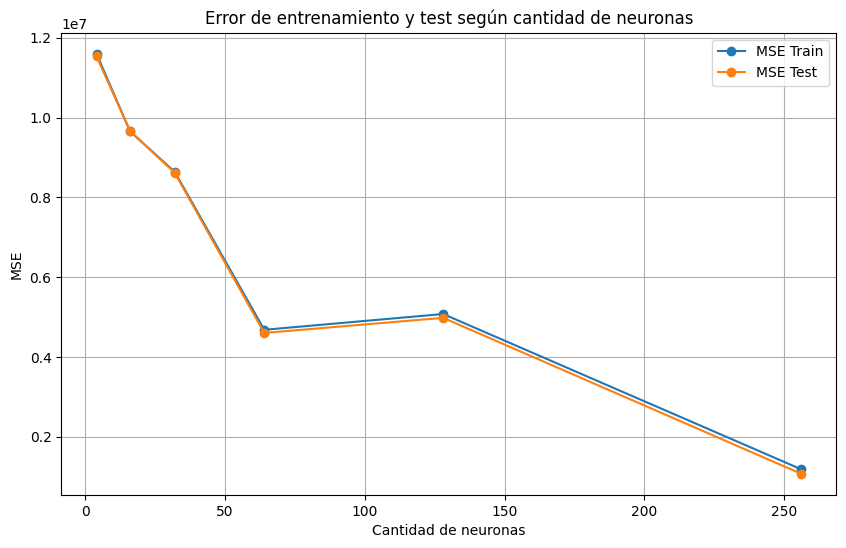

In [141]:
# ==========================================
# 2.3) Grafico
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    resultados_df["Neuronas"],
    resultados_df["MSE Train"],
    marker="o",
    label="MSE Train"
)

plt.plot(
    resultados_df["Neuronas"],
    resultados_df["MSE Test"],
    marker="o",
    label="MSE Test"
)

plt.xlabel("Cantidad de neuronas")
plt.ylabel("MSE")
plt.title("Error de entrenamiento y test según cantidad de neuronas")

plt.legend()
plt.grid(True)

plt.show()

# Conclusión

- Se utiliza **MSE (Mean Squared Error o Error Cuadrático Medio)** porque el problema es de **regresión**, ya que se busca predecir un valor numérico continuo: `GY` (rendimiento de soja).

- **Subajuste (Underfitting):**  
  Se presenta cuando ambos errores son altos:
  - MSE Train → alto
  - MSE Test → alto
  
  Esto indica que la red no logra aprender correctamente ni siquiera los datos de entrenamiento.

- **Sobreajuste (Overfitting):**  
  Se presenta cuando el modelo funciona muy bien con los datos de entrenamiento, pero presenta un error considerablemente mayor en los datos de test:
  - MSE Train → bajo
  - MSE Test → mucho más alto

  

## Análisis y conclusiones

En este experimento se modificó la cantidad de neuronas de la primera capa oculta de la red neuronal, utilizando 4, 16, 32, 64, 128 y 256 neuronas. Para cada arquitectura se calcularon los errores MSE sobre los conjuntos de entrenamiento y testeo.

Los resultados muestran que con 4 neuronas se obtienen errores elevados tanto en entrenamiento como en testeo:

- MSE Train = 11.602.013
- MSE Test = 11.534.256

Este comportamiento es compatible con **underfitting (subajuste)**, ya que la red tiene una capacidad limitada y no logra aprender correctamente el problema.

A medida que aumenta la cantidad de neuronas, el error disminuye en general. Con 64 neuronas el MSE Test disminuye hasta 4.602.053,5 y con 256 neuronas se obtiene el menor error del experimento, con un MSE Test de 1.073.247,625.

Se observa una pequeña variación entre 64 y 128 neuronas, ya que el MSE Test aumenta de 4.602.053,5 a 4.981.237,5. Sin embargo, esto no permite afirmar que exista sobreajuste, ya que el error de entrenamiento y el de testeo permanecen próximos.

En cuanto al **overfitting (sobreajuste)**, no se observa una zona clara en el experimento. Las curvas de MSE Train y MSE Test permanecen muy cercanas para las distintas cantidades de neuronas. Por ejemplo, con 256 neuronas se obtiene un MSE Train de 1.186.031,625 y un MSE Test de 1.073.247,625.

En conclusión, las redes con menor cantidad de neuronas presentan un comportamiento compatible con **underfitting**, mientras que al aumentar la capacidad de la red se reduce considerablemente el error. En el rango de arquitecturas evaluado no se observa evidencia clara de **overfitting**, ya que no aparece una separación importante entre los errores de entrenamiento y testeo.



### 2.4) Comparación con modelos de Aprendizaje Automático I (1 punto)

Compare la configuración de la red neuronal elegida con el desempeño de los **modelos de aprendizaje automático utilizados en el mismo notebook de AA1**.

### 2.4) Comparación con modelos de Aprendizaje Automático I

Se comparó la red neuronal desarrollada en PyTorch con el modelo de
regresión lineal utilizado en AA1, utilizando las mismas métricas de
evaluación.

| Métrica | Regresión Lineal Train | Red Neuronal Train | Regresión Lineal Test | Red Neuronal Test |
|---|---:|---:|---:|---:|
| R² | 0,589 | -33,483 | 0,523 | -32,267 |
| MSE | 103.078 | 8.638.664 | 123.529 | 8.613.402 |
| MAE | 253,62 | 2.891,40 | 274,92 | 2.888,40 |

En el conjunto de test, la regresión lineal obtuvo un R² de 0,523,
mientras que la red neuronal obtuvo un R² de -32,267. Además, el MSE
de la regresión lineal fue de 123.529 frente a 8.613.402 de la red
neuronal, y el MAE fue de 274,92 frente a 2.888,40.

Por lo tanto, con la configuración utilizada en el punto 2.2,
la regresión lineal presentó un menor error y un R² superior tanto
en entrenamiento como en test. En este experimento, la red neuronal
no logró superar el desempeño obtenido por el modelo de regresión
lineal utilizado en AA1.

* Una red neuronal tiene mayor capacidad de modelar relaciones complejas, pero eso no garantiza que vaya a superar a una regresión lineal en un conjunto de datos concreto.